# Notebook 6 — Early Warning Systems (EWS)

This notebook implements **Heat-Health Warning Systems (HHWWS)** as the third adaptation policy. Following Pavanello & Valenti (2024), we model EWS as a reduction in mortality on warning days:  
`avoided_deaths = deaths_on_warning_days × efficacy`.  
This captures the combined effect of behavioral responses (staying indoors, hydration) and healthcare activation triggered by alerts.

**Calibration:** Pavanello & Valenti (2024) found Italy's HHWWS reduced mortality on days ≥30°C by **22%** (HHWWS-only) to **57%** (full heat plan), with effects significant after ~3 years.

**Marginal interpretation:** Since Rome's HHWWS has operated since 2004, our baseline damage functions already embed its effect. To avoid double-counting, we model **marginal enhancements** (5–15% efficacy) rather than full counterfactual efficacy.

**Rome threshold:** **26°C** (85th percentile) instead of 30°C, yielding ~57 warning days/year.

**Parameters:** €140K CAPEX, €6K/warning day OPEX, 3-year ramp-up, **10%** central efficacy.

In [32]:
import os
os.environ["CITY"] = "rome"   # pick the city here

In [33]:
# generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: rome  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim


In [34]:
# city config + file paths from YAML 
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB2 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# checks
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: rome Rome
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/gviRome/gvi_Rome.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/rome_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/rome/CoolingEff/coefs_GVI_t2m.csv


# Imports

In [35]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import json
import rasterio as rio

from climada.hazard import Hazard
from climada.entity.exposures import Exposures

plt.rcParams.update({"figure.dpi": 130})

# STUDY PARAMETERS

In [36]:
STUDY_YEARS = cfg.get("climate", {}).get("years", [2020, 2030, 2040, 2050])

# Extract CBA config from YAML
cba_cfg = cfg.get("cba", {})
DISCOUNT_RATE = cba_cfg.get("discount_rate", 0.03)
HORIZON_YEARS = cba_cfg.get("horizon_years", 25)

# Extract EWS config from YAML (with fallback defaults)
ews_cfg = cfg.get("ews", {})

# EWS CONFIGURATION

In [37]:
EWS_CONFIG = {
    # Threshold settings 
    # Method: 'fixed' (use threshold_c) or 'percentile' (compute from data)
    'threshold_method': 'fixed',
    'threshold_c': 26.0,              # Used if method='fixed'
    'threshold_percentile': 85,       # Used if method='percentile'
    'threshold_ref_year': 2020,       # Reference year for percentile calc
    
    # Warning season (May-September)
    'warning_months': [5, 6, 7, 8, 9],
    
    # Efficacy scenarios 
    # INTERPRETATION A (Counterfactual): what if no HHWWS existed?
    # using full literature values: 20-50%
    'efficacy_counterfactual': {
        'low': 0.20,      # HHWWS-only (Italy paper)
        'central': 0.35,  # Between HHWWS and full plan
        'high': 0.50      # Full heat plan (Italy paper: 57%)
    },
    
    # INTERPRETATION B (Marginal): what additional benefit from enhancement?
    # More conservative since baseline already includes HHWWS effect
    'efficacy_marginal': {
        'low': 0.05,      # Modest improvement
        'central': 0.10,  # Moderate enhancement (better outreach)
        'high': 0.15      # Ambitious enhancement
    },
    
    # DEFAULT INTERPRETATION: 'marginal' or 'counterfactual'
    'interpretation': 'marginal',
    
    # Ramp-up period 
    # Italy paper (Figure 4c): effects NOT significant years 0-3
    # Step function: 10% efficacy years 0-2, 100% year 3+
    'ramp_years': 3,
    'ramp_initial_efficacy': 0.10,
    
    # Cost parameters 
    'capex_setup': 140_000,           # One-time setup
    'opex_per_warning_day': 6_000,    # Per warning day (system + response)
    'opex_annual_fixed': 50_000,      # Annual fixed maintenance
}

# Select efficacy based on interpretation
if EWS_CONFIG['interpretation'] == 'counterfactual':
    EFFICACY_SCENARIOS = EWS_CONFIG['efficacy_counterfactual']
    print("\n Using COUNTERFACTUAL interpretation (full literature efficacy)")
    print("   This shows what HHWWS prevents, not marginal benefit of enhancement")
else:
    EFFICACY_SCENARIOS = EWS_CONFIG['efficacy_marginal']
    print("\n Using MARGINAL interpretation (conservative efficacy)")
    print("  Baseline damage functions already embed existing HHWWS effect")

print("\n" + "=" * 70)
print("Notebook 5b: Early Warning System (HHWWS) Policy")
print("=" * 70)
print(f"\nConfiguration:")
print(f"  Interpretation: {EWS_CONFIG['interpretation'].upper()}")
print(f"  Warning threshold: {EWS_CONFIG['threshold_c']}°C")
print(f"  Warning season: months {EWS_CONFIG['warning_months']}")
print(f"  Efficacy scenarios: {EFFICACY_SCENARIOS}")
print(f"  Ramp-up: {EWS_CONFIG['ramp_years']} years (step function)")
print(f"  Discount rate: {DISCOUNT_RATE*100:.0f}%")
print(f"  Horizon: {HORIZON_YEARS} years")


 Using MARGINAL interpretation (conservative efficacy)
  Baseline damage functions already embed existing HHWWS effect

Notebook 5b: Early Warning System (HHWWS) Policy

Configuration:
  Interpretation: MARGINAL
  Warning threshold: 26.0°C
  Warning season: months [5, 6, 7, 8, 9]
  Efficacy scenarios: {'low': 0.05, 'central': 0.1, 'high': 0.15}
  Ramp-up: 3 years (step function)
  Discount rate: 3%
  Horizon: 25 years


# 1. LOAD DATA (matching NB5/NB6 patterns)

# 1.1 Reference grid and masks

In [38]:
import json, numpy as np, geopandas as gpd, rasterio as rio 

print("\n1.1 Loading reference grid...")

tmpl_path = INT / "template_ref.tif"
mask_tif  = INT / "city_mask.tif"

with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]

with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)

print(f"  Reference grid: {HGT}×{WDT} | CRS: {ref_meta['crs']}")
print(f"  CITY_MASK pixels: {CITY_MASK.sum():,}")


1.1 Loading reference grid...
  Reference grid: 301×301 | CRS: EPSG:3035
  CITY_MASK pixels: 77,929


# 1.2 Load hazard with dates

In [39]:
print("\n1.2 Loading hazard data...")

def _days_in_year(y):
    return 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365

def reattach_daily_dates(INT, SLUG, H):
    csv = Path(INT) / f"hazard_T2M_daily_events_{SLUG}.csv"
    df = pd.read_csv(csv).sort_values("row").reset_index(drop=True)
    n = H.intensity.shape[0]
    assert len(df) == n, f"Events CSV rows ({len(df)}) != hazard rows ({n})."
    H.event_id   = df["event_id"].to_numpy(int)
    H.date       = pd.to_datetime(df["date"]).to_numpy("datetime64[ns]")
    H.event_name = np.array([f"T2M_{d.date()}" for d in pd.to_datetime(df["date"])], dtype=object)
    yrs = pd.to_datetime(df["date"]).dt.year.to_numpy(int)
    H.frequency      = np.array([1.0/_days_in_year(y) for y in yrs], dtype=float)
    H.frequency_unit = "1/year"
    return H

haz_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
H = Hazard.from_hdf5(haz_path)
H = reattach_daily_dates(INT, SLUG, H)
H.haz_type = "T2M"
H.units    = "degC (daily mean)"

dates_h = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
YEARS_H = np.sort(dates_h.dt.year.unique()).astype(int).tolist()
print(f"  Loaded hazard: {H.intensity.shape[0]} events × {H.intensity.shape[1]} cells")
print(f"  Years: {YEARS_H}")


1.2 Loading hazard data...
  Loaded hazard: 1462 events × 90601 cells
  Years: [2020, 2030, 2040, 2050]


# 1.3 Load exposure by year (from manifest)

In [40]:
print("\n1.3 Loading exposure data...")

age_npz = INT / f"age_on_ref_{SLUG}.npz"
if not age_npz.exists(): age_npz = INT / "age_on_ref.npz"
pop_npz = INT / f"pop_on_ref_{SLUG}.npz"
if not pop_npz.exists(): pop_npz = INT / "pop_on_ref.npz"

agez = np.load(age_npz)
age_on_ref = {"<15": agez["lt15"], "15-64": agez["a15_64"], "65+": agez["g65"]}
pop_on_ref = np.load(pop_npz)["pop"]

expo_manifest_path = INT / "exposure_manifest.json"
with open(expo_manifest_path) as f:
    expo_manifest = json.load(f)

# Scenario selection
scen_dict = expo_manifest.get("scenarios", {})
scenario_cfg = (cfg or {}).get("scenario", {}) or {}
SCEN_CODE = scenario_cfg.get("code")
if not SCEN_CODE:
    SCEN_CODE = cfg.get("exp_scenario")
if (not SCEN_CODE or SCEN_CODE not in scen_dict):
    ac_cfg_tmp = cfg.get("ac", {})
    ssp = ac_cfg_tmp.get("ssp", None)
    if ssp is not None:
        for cand in (f"SSP{ssp}", f"ssp{ssp}", f"ssp{ssp}".lower(), f"SSP{ssp}".upper()):
            if cand in scen_dict:
                SCEN_CODE = cand
                break
if not SCEN_CODE or SCEN_CODE not in scen_dict:
    SCEN_CODE = sorted(scen_dict.keys())[0]
print(f"  Using exposure scenario: {SCEN_CODE}")

baseline_rec = expo_manifest.get("baseline", {})
BASELINE_YEAR = baseline_rec.get("year", 2020)

age_on_ref_by_year = {}
pop_on_ref_by_year = {}

for y in YEARS_H:
    if y == BASELINE_YEAR:
        if "age_npz" in baseline_rec and "pop_npz" in baseline_rec:
            ages_npz = np.load(baseline_rec["age_npz"])
            pop_npz_file = np.load(baseline_rec["pop_npz"])
        else:
            age_on_ref_by_year[int(y)] = {
                "<15":   age_on_ref["<15"].astype("float32"),
                "15-64": age_on_ref["15-64"].astype("float32"),
                "65+":   age_on_ref["65+"].astype("float32"),
            }
            pop_on_ref_by_year[int(y)] = pop_on_ref.astype("float32")
            print(f"    {y}: Using pre-loaded baseline arrays")
            continue
    else:
        scen_rec = scen_dict[SCEN_CODE]
        rec_y = scen_rec.get(str(y))
        if rec_y is None:
            raise KeyError(f"No exposure entry for scenario {SCEN_CODE}, year {y}")
        ages_npz = np.load(rec_y["age_npz"])
        pop_npz_file = np.load(rec_y["pop_npz"])
    
    age_on_ref_by_year[int(y)] = {
        "<15":   ages_npz["lt15"].astype("float32"),
        "15-64": ages_npz["a15_64"].astype("float32"),
        "65+":   ages_npz["g65"].astype("float32"),
    }
    pop_on_ref_by_year[int(y)] = pop_npz_file["pop"].astype("float32")
    print(f"    {y}: Loaded from {'baseline' if y == BASELINE_YEAR else 'scenario ' + SCEN_CODE}")


1.3 Loading exposure data...
  Using exposure scenario: SSP2
    2020: Using pre-loaded baseline arrays
    2030: Loaded from scenario SSP2
    2040: Loaded from scenario SSP2
    2050: Loaded from scenario SSP2


# 1.4 Load IF curves by year (from NB4)

In [41]:
print("\n1.4 Loading impact function curves...")

def load_if_curves_by_year(INT, OUT, slug):
    """
    Load year-specific IF curves from NB4 output.
    NB4 saves to: INT / f"if_curves_by_year_{slug}.json"
    
    JSON structure:
    {
        "reference_year": 2020,
        "years": [2020, 2030, ...],
        "ifs_by_year": {
            "2020": {"<15": {...}, "15-64": {...}, "65+": {...}},
            ...
        }
    }
    """
    candidates = [
        INT / f"if_curves_by_year_{slug}.json",    # NB4 primary
        INT / f"if_curves_frozen_{slug}.json",      # NB4 legacy
        INT / "if_curves_by_year.json",             # generic
        OUT / f"if_curves_by_year_{slug}.json",
    ]
    p = None
    for c in candidates:
        if c.exists():
            p = c
            print(f"    Found IF curves: {c}")
            break
    if p is None:
        raise FileNotFoundError(
            f"Missing IF bundle JSON for {slug}.\n"
            f"Expected one of: {[str(c) for c in candidates]}\n"
            f"Please run NB4 first to generate IF curves."
        )
    
    with open(p, "r") as f:
        obj = json.load(f)
    
    # NB6 pattern: extract ifs_by_year from the JSON structure
    raw = obj.get("ifs_by_year", {})
    if not raw:
        # Fallback: maybe the JSON is directly year->age->curves
        # Check if keys are year-like integers
        if all(k.isdigit() for k in obj.keys() if k not in ["reference_year", "years", "scaling_source"]):
            raw = {k: v for k, v in obj.items() if k.isdigit()}
        else:
            raise ValueError(f"{p.name} has no 'ifs_by_year' key and doesn't appear to be a direct year->curves mapping.")
    
    # Build IFS_BY_YEAR dict with int keys
    IFS_BY_YEAR = {}
    for y_key, d in raw.items():
        y = int(y_key)
        IFS_BY_YEAR[y] = {}
        for age_lbl, curves in d.items():
            IFS_BY_YEAR[y][age_lbl] = {
                "intensity": np.asarray(curves["intensity"], float),
                "mdd": np.asarray(curves["mdd"], float),
            }
    
    # Build getter function (matching NB6 pattern)
    def get_age_ifs_for_year(year: int):
        """Get age-specific impact functions for a given year."""
        year = int(year)
        if year not in IFS_BY_YEAR:
            raise KeyError(f"No SCALED IFs for year {year}. Available: {sorted(IFS_BY_YEAR.keys())}")
        return IFS_BY_YEAR[year]
    
    # Extract metadata
    meta = {
        "reference_year": obj.get("reference_year", None),
        "years": obj.get("years", sorted(IFS_BY_YEAR.keys())),
    }
    
    age_labels = list(next(iter(IFS_BY_YEAR.values())).keys())
    return get_age_ifs_for_year, age_labels, meta

get_age_ifs_for_year, IF_AGE_LABELS, IF_META = load_if_curves_by_year(INT, OUT, SLUG)
print(f"  Loaded IF curves, age groups: {IF_AGE_LABELS}")
print(f"  Years available: {IF_META['years']}")


1.4 Loading impact function curves...
    Found IF curves: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/if_curves_by_year_rome.json
  Loaded IF curves, age groups: ['<15', '15-64', '65+']
  Years available: [2020, 2030, 2040, 2050]


# 1.5 Load AC coverage (baseline from NB5)

In [42]:
print("\n1.5 Loading AC coverage (baseline)...")

def load_ac_coverage_current(INT, OUT, slug):
    """
    Load AC baseline coverage from NB5 output.
    NB5 saves to: INT / f"ac_coverage_maps_{slug}.npz"
    with keys: coverage_base_3d, coverage_policy_3d, YEARS_AC
    """
    candidates = [
        INT / f"ac_coverage_maps_{slug}.npz",   # NB5 primary output
        INT / "ac_coverage_maps.npz",            # NB5 legacy output
        OUT / f"ac_coverage_maps_{slug}.npz",
    ]
    p = None
    for c in candidates:
        if c.exists():
            p = c
            print(f"    Found AC file: {c}")
            break
    if p is None:
        raise FileNotFoundError(
            f"Missing AC NPZ output from NB5 for {slug}.\n"
            f"Expected one of: {[str(c) for c in candidates]}\n"
            f"Please run NB5 first to generate AC coverage maps."
        )
    
    z = np.load(p, allow_pickle=True)
    print(f"    NPZ keys: {list(z.keys())}")
    
    if "coverage_base_3d" in z and "YEARS_AC" in z:
        years = [int(x) for x in z["YEARS_AC"]]
        cov3d = z["coverage_base_3d"]
        coverage_by_year = {y: cov3d[i].astype("float32") for i, y in enumerate(years)}
    else:
        raise KeyError(
            f"AC NPZ missing expected keys. Found: {list(z.keys())}\n"
            f"Need: coverage_base_3d, YEARS_AC"
        )
    
    return coverage_by_year

coverage_base_by_year = load_ac_coverage_current(INT, OUT, SLUG)
YEARS_AC = sorted(coverage_base_by_year.keys())
print(f"  Loaded AC baseline coverage for years: {YEARS_AC}")

# AC efficacy by age (from YAML)
eff_cfg = cfg.get("efficacy", {})
EFF_BY_AGE = {k: float(v) for k, v in eff_cfg.items() if k != "default"}
EFF_DEFAULT = float(eff_cfg.get("default", 0.30))
print(f"  AC efficacy by age: {EFF_BY_AGE}, default: {EFF_DEFAULT}")


1.5 Loading AC coverage (baseline)...
    Found AC file: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/interim/ac_coverage_maps_rome.npz
    NPZ keys: ['coverage_base_3d', 'coverage_policy_3d', 'YEARS_AC', 'years', 'coverage_base', 'coverage_policy', 'ANCHOR_YEAR', 'CITY_MASK', 'CAP_PIX', 'CAP_MASK_ANCHOR', 'HGT', 'WDT', 'EFF_SCENARIO', 'EFF_DEFAULT', 'EFF_BUCKETS_LT15', 'EFF_BUCKETS_15_64', 'EFF_BUCKETS_65P']
  Loaded AC baseline coverage for years: [2020, 2030, 2040, 2050]
  AC efficacy by age: {'<15': 0.2, '15-64': 0.3, '65+': 0.4}, default: 0.3


# 2. COMPUTE BASELINE DEATHS UNDER CURRENT AC (like NB6)

In [44]:
print("\n" + "=" * 70)
print("2. COMPUTING BASELINE DEATHS (under current AC)")
print("=" * 70)

def _row_to_1d(mat, i):
    """Get i-th row as 1D float array; supports scipy sparse."""
    row = mat[i]
    if hasattr(row, "toarray"):
        row = row.toarray()
    return np.asarray(row, float).ravel()

def compute_citymean_daily(H, city_mask_1d):
    """Compute city-mean temperature for each day, using only city pixels."""
    dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
    cm = []
    for i in range(H.intensity.shape[0]):
        I = _row_to_1d(H.intensity, i)
        # Use city mask to compute mean over city pixels only
        m = city_mask_1d & np.isfinite(I)
        cm.append(float(np.nanmean(I[m])) if np.any(m) else np.nan)
    return dates, np.asarray(cm, float)

def daily_deaths_current_ac(H, city_mask_1d, age_by_year, coverage_by_year, 
                            get_age_ifs_for_year,
                            eff_by_age: dict, eff_default: float = 0.30):
    """
    Compute daily deaths under current AC coverage.
    This matches NB5's death computation: np.nansum(pop * mdd * mult)
    """
    dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
    years = dates.dt.year.astype(int).to_numpy()
    
    # Infer age labels
    age_labels = list(next(iter(age_by_year.values())).keys())
    
    rows = []
    for i, dt in enumerate(dates):
        y = int(years[i])
        
        I = _row_to_1d(H.intensity, i)
        cov = np.nan_to_num(np.asarray(coverage_by_year[y], float).ravel(), nan=0.0)
        
        age_ifs = get_age_ifs_for_year(y)
        deaths_age = {}
        
        # Mask: city pixels with valid temperature
        m = city_mask_1d & np.isfinite(I)
        
        for a in age_labels:
            pop = np.nan_to_num(np.asarray(age_by_year[y][a], float).ravel(), nan=0.0)
            
            f = age_ifs[a]
            mdd = np.interp(I, f["intensity"], f["mdd"], left=f["mdd"][0], right=f["mdd"][-1])
            
            eff_a = float(eff_by_age.get(a, eff_default))
            mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)
            
            # Death computation matches NB5: np.nansum(pop * mdd * mult)
            deaths = float(np.nansum(pop[m] * mdd[m] * mult[m]))
            deaths_age[a] = deaths
        
        rows.append({
            "date": dt,
            "year": int(dt.year),
            "month": int(dt.month),
            **{f"deaths_{a}": v for a, v in deaths_age.items()},
            "deaths_overall": float(sum(deaths_age.values()))
        })
    
    return pd.DataFrame(rows)

# Compute daily baseline deaths
print("\n2.1 Computing daily deaths under current AC...")

# Flatten city mask for vectorized operations
CITY_MASK_1D = CITY_MASK.ravel()

daily_base = daily_deaths_current_ac(
    H=H,
    city_mask_1d=CITY_MASK_1D,
    age_by_year=age_on_ref_by_year,
    coverage_by_year=coverage_base_by_year,
    get_age_ifs_for_year=get_age_ifs_for_year,
    eff_by_age=EFF_BY_AGE,
    eff_default=EFF_DEFAULT,
)

# Attach city-mean temperature for thresholding
print("2.2 Attaching city-mean temperature...")
dates_h, citymean = compute_citymean_daily(H, CITY_MASK_1D)
daily_base = daily_base.merge(
    pd.DataFrame({"date": dates_h, "citymean_degC": citymean}), 
    on="date", how="left"
)

# Aggregate to annual
annual_base = daily_base.groupby("year", as_index=False).sum(numeric_only=True)
print(f"\n  Annual baseline deaths (under current AC):")
for _, r in annual_base.iterrows():
    print(f"    {int(r['year'])}: {r['deaths_overall']:.1f} deaths")


2. COMPUTING BASELINE DEATHS (under current AC)

2.1 Computing daily deaths under current AC...
2.2 Attaching city-mean temperature...

  Annual baseline deaths (under current AC):
    2020: 467.8 deaths
    2030: 553.4 deaths
    2040: 602.6 deaths
    2050: 595.0 deaths


# 3. DEFINE WARNING DAYS AND COMPUTE DEATHS ON WARNING DAYS

In [45]:
print("\n" + "=" * 70)
print("3. COMPUTING WARNING DAYS AND DEATHS ON WARNING DAYS")
print("=" * 70)

def pick_threshold(daily_df, ews_cfg):
    """Determine threshold using fixed value or percentile method."""
    method = ews_cfg.get("threshold_method", "fixed")
    warm_months = ews_cfg["warning_months"]
    
    if method == "fixed":
        return float(ews_cfg["threshold_c"]), {"method": "fixed"}
    
    if method == "percentile":
        p = float(ews_cfg.get("threshold_percentile", 85))
        ref_year = int(ews_cfg.get("threshold_ref_year", daily_df["year"].min()))
        warm = daily_df["month"].isin(warm_months) & (daily_df["year"] == ref_year)
        thr = float(np.nanpercentile(daily_df.loc[warm, "citymean_degC"], p))
        return thr, {"method": "percentile", "percentile": p, "ref_year": ref_year}
    
    raise ValueError(f"Unknown threshold_method: {method}")

# Determine threshold
thr, thr_meta = pick_threshold(daily_base, EWS_CONFIG)
print(f"\n3.1 Threshold determination:")
print(f"    Method: {thr_meta['method']}")
print(f"    Threshold: {thr:.1f}°C")

# Identify warning days
warm_months = EWS_CONFIG["warning_months"]
daily_base["is_warning_day"] = (
    daily_base["month"].isin(warm_months) & 
    (daily_base["citymean_degC"] >= thr)
)

# Count warning days per year
warning_day_counts = (
    daily_base[daily_base["is_warning_day"]]
    .groupby("year")
    .size()
    .reset_index(name="n_warning_days")
)
print(f"\n3.2 Warning days per year (T ≥ {thr:.1f}°C):")
for _, r in warning_day_counts.iterrows():
    print(f"    {int(r['year'])}: {int(r['n_warning_days'])} days")

# Compute deaths on warning days (ENDOGENOUS, not assumed)
annual_warn = (
    daily_base[daily_base["is_warning_day"]]
    .groupby("year", as_index=False)
    .sum(numeric_only=True)
    .rename(columns={"deaths_overall": "deaths_on_warning_days"})
)

annual_base = annual_base.merge(
    annual_warn[["year", "deaths_on_warning_days"]], 
    on="year", how="left"
)
annual_base["deaths_on_warning_days"] = annual_base["deaths_on_warning_days"].fillna(0.0)
annual_base["frac_deaths_on_warning_days"] = (
    annual_base["deaths_on_warning_days"] / annual_base["deaths_overall"]
).replace([np.inf, -np.inf], np.nan)

print(f"\n3.3 Deaths on warning days (computed, not assumed):")
for _, r in annual_base.iterrows():
    frac = r["frac_deaths_on_warning_days"]
    print(f"    {int(r['year'])}: {r['deaths_on_warning_days']:.1f} deaths "
          f"({frac*100:.1f}% of annual)")

# Add warning day counts to annual_base
annual_base = annual_base.merge(warning_day_counts, on="year", how="left")


3. COMPUTING WARNING DAYS AND DEATHS ON WARNING DAYS

3.1 Threshold determination:
    Method: fixed
    Threshold: 26.0°C

3.2 Warning days per year (T ≥ 26.0°C):
    2020: 45 days
    2030: 59 days
    2040: 62 days
    2050: 60 days

3.3 Deaths on warning days (computed, not assumed):
    2020: 324.7 deaths (69.4% of annual)
    2030: 454.1 deaths (82.1% of annual)
    2040: 512.0 deaths (85.0% of annual)
    2050: 494.5 deaths (83.1% of annual)


# 4. CALCULATE EWS BENEFITS

In [46]:
print("\n" + "=" * 70)
print("4. CALCULATING EWS BENEFITS")
print("=" * 70)

def ews_ramp_efficacy(year, start_year, efficacy_full, ramp_years=3, initial_frac=0.10):
    """
    Step-function ramp-up: 
    - Years 0 to ramp_years-1: initial_frac * efficacy_full
    - Years ramp_years+: efficacy_full
    """
    ys = year - start_year
    if ys < 0:
        return 0.0
    if ys < ramp_years:
        return float(efficacy_full) * float(initial_frac)
    return float(efficacy_full)

EWS_START_YEAR = min(annual_base["year"])
print(f"\n  EWS start year: {EWS_START_YEAR}")
print(f"  Ramp-up: {EWS_CONFIG['ramp_years']} years at {EWS_CONFIG['ramp_initial_efficacy']*100:.0f}% efficacy")

# Build benefits table by scenario
rows = []
for _, r in annual_base.iterrows():
    y = int(r["year"])
    total = float(r["deaths_overall"])
    warn_deaths = float(r["deaths_on_warning_days"])
    n_warn_days = int(r.get("n_warning_days", 0))
    frac = float(r["frac_deaths_on_warning_days"]) if np.isfinite(r["frac_deaths_on_warning_days"]) else np.nan
    
    for scen, eff_full in EFFICACY_SCENARIOS.items():
        eff = ews_ramp_efficacy(
            y, EWS_START_YEAR, eff_full,
            ramp_years=EWS_CONFIG["ramp_years"],
            initial_frac=EWS_CONFIG["ramp_initial_efficacy"],
        )
        
        # EWS reduces deaths ONLY on warning days
        avoided = warn_deaths * eff
        
        rows.append({
            "year": y,
            "scenario": scen,
            "interpretation": EWS_CONFIG['interpretation'],
            "threshold_c": thr,
            "n_warning_days": n_warn_days,
            "baseline_deaths_current_ac": total,
            "deaths_on_warning_days": warn_deaths,
            "frac_deaths_on_warning_days": frac,
            "efficacy_full": float(eff_full),
            "efficacy_effective": float(eff),
            "avoided_deaths": float(avoided),
            "deaths_with_ews": float(total - avoided),
            "pct_reduction": float(avoided / total * 100.0) if total > 0 else 0.0,
        })

ews_benefits_df = pd.DataFrame(rows)

print(f"\n  EWS avoided deaths by year and scenario:")
pivot = ews_benefits_df.pivot(index="year", columns="scenario", values="avoided_deaths")
print(pivot.round(2).to_string())


4. CALCULATING EWS BENEFITS

  EWS start year: 2020
  Ramp-up: 3 years at 10% efficacy

  EWS avoided deaths by year and scenario:
scenario  central   high    low
year                           
2020         3.25   4.87   1.62
2030        45.41  68.11  22.70
2040        51.20  76.79  25.60
2050        49.45  74.18  24.73


# 5. COST CALCULATION

In [47]:
print("\n" + "=" * 70)
print("5. COST CALCULATION")
print("=" * 70)

def calculate_ews_costs(years, warning_days_by_year, ews_cfg, discount_rate):
    """Calculate annual and present value costs for EWS."""
    capex = ews_cfg['capex_setup']
    opex_per_day = ews_cfg['opex_per_warning_day']
    opex_fixed = ews_cfg['opex_annual_fixed']
    
    start_year = min(years)
    rows = []
    
    for y in years:
        t = y - start_year
        n_days = warning_days_by_year.get(y, 50)
        
        # Year 0: CAPEX + OPEX; other years: OPEX only (SHOULD I PUT CAPEX YEAR 0?)
        cost_capex = capex if t == 0 else 0
        cost_opex_variable = opex_per_day * n_days
        cost_opex_fixed = opex_fixed
        cost_total = cost_capex + cost_opex_variable + cost_opex_fixed
        
        # Discount
        df = (1 + discount_rate) ** t
        cost_pv = cost_total / df
        
        rows.append({
            "year": y,
            "t": t,
            "n_warning_days": n_days,
            "cost_capex": cost_capex,
            "cost_opex_variable": cost_opex_variable,
            "cost_opex_fixed": cost_opex_fixed,
            "cost_total": cost_total,
            "discount_factor": df,
            "cost_pv": cost_pv,
        })
    
    return pd.DataFrame(rows)

# Build warning days dict
warning_days_dict = dict(zip(
    warning_day_counts["year"].astype(int), 
    warning_day_counts["n_warning_days"].astype(int)
))

costs_df = calculate_ews_costs(
    years=YEARS_H,
    warning_days_by_year=warning_days_dict,
    ews_cfg=EWS_CONFIG,
    discount_rate=DISCOUNT_RATE
)

print(f"\n  Annual costs:")
for _, r in costs_df.iterrows():
    print(f"    {int(r['year'])}: €{r['cost_total']:,.0f} "
          f"(CAPEX: €{r['cost_capex']:,.0f}, OPEX: €{r['cost_opex_variable'] + r['cost_opex_fixed']:,.0f})")

pv_total_cost = costs_df["cost_pv"].sum()
print(f"\n  Total PV cost (study period): €{pv_total_cost:,.0f}")


5. COST CALCULATION

  Annual costs:
    2020: €460,000 (CAPEX: €140,000, OPEX: €320,000)
    2030: €404,000 (CAPEX: €0, OPEX: €404,000)
    2040: €422,000 (CAPEX: €0, OPEX: €422,000)
    2050: €410,000 (CAPEX: €0, OPEX: €410,000)

  Total PV cost (study period): €1,163,180


# 5b. 25-YEAR HORIZON EXPANSION (for NB8 CBA consistency)


In [48]:
print("\n" + "=" * 70)
print("5b. 25-YEAR HORIZON EXPANSION")
print("=" * 70)


5b. 25-YEAR HORIZON EXPANSION


### 5b.1 Define 25-year horizon


In [49]:
import numpy as np

YEARS_ALL = np.arange(2020, 2020 + HORIZON_YEARS)  # [2020, 2021, ..., 2044]
T = len(YEARS_ALL)
print(f"\n  Horizon: {YEARS_ALL[0]} to {YEARS_ALL[-1]} ({T} years)")


  Horizon: 2020 to 2044 (25 years)


### 5b.2 Interpolate warning days to 25 years

In [50]:
# Anchor values from Section 3
anchor_years = warning_day_counts["year"].values
anchor_warning_days = warning_day_counts["n_warning_days"].values

# Linear interpolation
warning_days_25y = np.interp(YEARS_ALL, anchor_years, anchor_warning_days)

print(f"\n  Warning days interpolated:")
print(f"    Anchor: {dict(zip(anchor_years, anchor_warning_days))}")
print(f"    Range over 25y: {warning_days_25y.min():.0f} - {warning_days_25y.max():.0f} days/year")


  Warning days interpolated:
    Anchor: {2020: 45, 2030: 59, 2040: 62, 2050: 60}
    Range over 25y: 45 - 62 days/year


### 5b.3 Interpolate deaths on warning days to 25 years


In [51]:
anchor_deaths_warning = annual_base.set_index("year")["deaths_on_warning_days"]

deaths_warning_25y = np.interp(YEARS_ALL, anchor_deaths_warning.index, anchor_deaths_warning.values)

print(f"\n  Deaths on warning days interpolated:")
print(f"    Anchor: {anchor_deaths_warning.round(1).to_dict()}")
print(f"    Range over 25y: {deaths_warning_25y.min():.1f} - {deaths_warning_25y.max():.1f} deaths/year")


  Deaths on warning days interpolated:
    Anchor: {2020: 324.7, 2030: 454.1, 2040: 512.0, 2050: 494.5}
    Range over 25y: 324.7 - 512.0 deaths/year


### 5b.4 Compute efficacy ramp over 25 years


In [52]:
# Years 0-2: 10% of full efficacy; Year 3+: 100%
ramp_years = EWS_CONFIG["ramp_years"]
initial_frac = EWS_CONFIG["ramp_initial_efficacy"]

t_index = np.arange(T)  # 0, 1, 2, ..., 24
ramp_factor_25y = np.where(t_index < ramp_years, initial_frac, 1.0)

print(f"\n  Efficacy ramp:")
print(f"    Years 0-{ramp_years-1}: {initial_frac*100:.0f}% of full efficacy")
print(f"    Years {ramp_years}+: 100% of full efficacy")


  Efficacy ramp:
    Years 0-2: 10% of full efficacy
    Years 3+: 100% of full efficacy


### 5b.5 Compute costs over 25 years


In [53]:
capex = EWS_CONFIG["capex_setup"]
opex_fixed = EWS_CONFIG["opex_annual_fixed"]
opex_per_day = EWS_CONFIG["opex_per_warning_day"]

# CAPEX only in year 0
cost_capex_25y = np.zeros(T)
cost_capex_25y[0] = capex

# OPEX every year
cost_opex_fixed_25y = np.full(T, opex_fixed)
cost_opex_var_25y = opex_per_day * warning_days_25y
cost_opex_25y = cost_opex_fixed_25y + cost_opex_var_25y

# Total
cost_total_25y = cost_capex_25y + cost_opex_25y

# Discount factors
discount_factors_25y = (1 + DISCOUNT_RATE) ** t_index
cost_pv_25y = cost_total_25y / discount_factors_25y

print(f"\n  Costs over 25 years:")
print(f"    Year 0: €{cost_total_25y[0]:,.0f} (CAPEX: €{capex:,} + OPEX: €{cost_opex_25y[0]:,.0f})")
print(f"    Years 1-24 avg: €{cost_total_25y[1:].mean():,.0f}/year (OPEX only)")
print(f"    PV total: €{cost_pv_25y.sum():,.0f}")


  Costs over 25 years:
    Year 0: €460,000 (CAPEX: €140,000 + OPEX: €320,000)
    Years 1-24 avg: €394,875/year (OPEX only)
    PV total: €7,053,088


### 5b.6 Compute avoided deaths over 25 years by scenario

In [54]:
ews_benefits_25y_rows = []

for scen, eff_full in EFFICACY_SCENARIOS.items():
    # Effective efficacy = full efficacy × ramp factor
    eff_25y = eff_full * ramp_factor_25y
    
    # Avoided deaths
    avoided_25y = deaths_warning_25y * eff_25y
    
    # PV of avoided deaths
    avoided_pv_25y = avoided_25y / discount_factors_25y
    
    for i, y in enumerate(YEARS_ALL):
        ews_benefits_25y_rows.append({
            "year": int(y),
            "scenario": scen,
            "efficacy_full": eff_full,
            "ramp_factor": ramp_factor_25y[i],
            "efficacy_effective": eff_25y[i],
            "deaths_on_warning_days": deaths_warning_25y[i],
            "avoided_deaths": avoided_25y[i],
            "avoided_deaths_pv": avoided_pv_25y[i],
            "warning_days": warning_days_25y[i],
            "cost_total": cost_total_25y[i],
            "cost_pv": cost_pv_25y[i],
        })

ews_25y_df = pd.DataFrame(ews_benefits_25y_rows)

# Summary by scenario
print(f"\n  Avoided deaths over 25 years (cumulative):")
for scen in EFFICACY_SCENARIOS.keys():
    scen_data = ews_25y_df[ews_25y_df["scenario"] == scen]
    cum = scen_data["avoided_deaths"].sum()
    pv = scen_data["avoided_deaths_pv"].sum()
    print(f"    {scen}: {cum:.1f} cumulative, {pv:.1f} PV")


  Avoided deaths over 25 years (cumulative):
    low: 513.0 cumulative, 345.5 PV
    central: 1026.1 cumulative, 691.0 PV
    high: 1539.1 cumulative, 1036.5 PV


### 5b.7 Build summary for NB8


In [55]:
pv_cost_total = cost_pv_25y.sum()

ews_25y_summary = {}
for scen in EFFICACY_SCENARIOS.keys():
    scen_data = ews_25y_df[ews_25y_df["scenario"] == scen]
    cum_avoided = scen_data["avoided_deaths"].sum()
    pv_avoided = scen_data["avoided_deaths_pv"].sum()
    
    ews_25y_summary[scen] = {
        "avoided_deaths_cum": cum_avoided,
        "avoided_deaths_pv": pv_avoided,
        "cost_pv": pv_cost_total,
        "cost_per_death_pv": pv_cost_total / pv_avoided if pv_avoided > 0 else np.inf,
        "cost_per_death_cum": pv_cost_total / cum_avoided if cum_avoided > 0 else np.inf,
    }

print(f"\n  Cost-effectiveness (25-year horizon):")
for scen, vals in ews_25y_summary.items():
    print(f"    {scen}: €{vals['cost_per_death_cum']:,.0f}/death (cumulative), "
          f"€{vals['cost_per_death_pv']:,.0f}/death (PV)")

# Store for later use
EWS_25Y_DF = ews_25y_df.copy()
EWS_25Y_SUMMARY = ews_25y_summary.copy()
PV_EWS_COST_25Y = pv_cost_total


  Cost-effectiveness (25-year horizon):
    low: €13,747/death (cumulative), €20,415/death (PV)
    central: €6,874/death (cumulative), €10,207/death (PV)
    high: €4,582/death (cumulative), €6,805/death (PV)


# 6. COST-EFFECTIVENESS ANALYSIS

**anchor year**

In [56]:
print("\n" + "=" * 70)
print("6. COST-EFFECTIVENESS ANALYSIS")
print("=" * 70)

# Present value of avoided deaths by scenario
cea_results = []
for scen in EFFICACY_SCENARIOS.keys():
    scen_df = ews_benefits_df[ews_benefits_df["scenario"] == scen].copy()
    scen_df = scen_df.merge(costs_df[["year", "discount_factor"]], on="year")
    
    # Discounted avoided deaths
    scen_df["avoided_deaths_pv"] = scen_df["avoided_deaths"] / scen_df["discount_factor"]
    total_avoided_pv = scen_df["avoided_deaths_pv"].sum()
    
    # Cumulative avoided deaths (undiscounted)
    total_avoided_cum = scen_df["avoided_deaths"].sum()
    
    # Cost per avoided death
    cost_per_death_pv = pv_total_cost / total_avoided_pv if total_avoided_pv > 0 else np.inf
    cost_per_death_cum = pv_total_cost / total_avoided_cum if total_avoided_cum > 0 else np.inf  

    cea_results.append({
        "scenario": scen,
        "pv_total_cost": pv_total_cost,
        "pv_avoided_deaths": total_avoided_pv,
        "avoided_deaths_cum": total_avoided_cum,  
        "cost_per_avoided_death_eur": cost_per_death_pv,
        "cost_per_avoided_death_cum_eur": cost_per_death_cum,  
    })

cea_df = pd.DataFrame(cea_results)

print(f"\n  Cost-effectiveness (interpretation: {EWS_CONFIG['interpretation'].upper()}):")
for _, r in cea_df.iterrows():
    print(f"    {r['scenario']}: €{r['cost_per_avoided_death_eur']:,.0f}/death (PV), "
          f"€{r['cost_per_avoided_death_cum_eur']:,.0f}/death (cumulative)")


6. COST-EFFECTIVENESS ANALYSIS

  Cost-effectiveness (interpretation: MARGINAL):
    low: €27,128/death (PV), €15,581/death (cumulative)
    central: €13,564/death (PV), €7,791/death (cumulative)
    high: €9,043/death (PV), €5,194/death (cumulative)


**interpolated**

In [57]:
# 6.2 Cost-effectiveness with 25-year horizon (for NB8 consistency)

print(f"\n  Cost-effectiveness (25-year horizon, interpretation: {EWS_CONFIG['interpretation'].upper()}):")
for scen, vals in EWS_25Y_SUMMARY.items():
    print(f"    {scen}: €{vals['cost_per_death_cum']:,.0f}/death (cumulative), "
          f"€{vals['cost_per_death_pv']:,.0f}/death (PV)")

# Compare anchor vs 25-year
print(f"\n  Comparison (central scenario):")
anchor_cum = cea_df[cea_df['scenario'] == 'central']['avoided_deaths_cum'].iloc[0]
horizon_cum = EWS_25Y_SUMMARY['central']['avoided_deaths_cum']
print(f"    Anchor years (4):  {anchor_cum:.1f} avoided deaths")
print(f"    Full horizon (25): {horizon_cum:.1f} avoided deaths")
print(f"    Ratio: {horizon_cum/anchor_cum:.2f}x (expected ~6.25x for linear interpolation)")

# Build comparison dataframe for 25-year (for visualization)
cea_25y_df = pd.DataFrame([
    {
        "scenario": scen,
        "pv_total_cost": vals["cost_pv"],
        "pv_avoided_deaths": vals["avoided_deaths_pv"],
        "avoided_deaths_cum": vals["avoided_deaths_cum"],
        "cost_per_avoided_death_eur": vals["cost_per_death_pv"],
        "cost_per_avoided_death_cum_eur": vals["cost_per_death_cum"],
    }
    for scen, vals in EWS_25Y_SUMMARY.items()
])


  Cost-effectiveness (25-year horizon, interpretation: MARGINAL):
    low: €13,747/death (cumulative), €20,415/death (PV)
    central: €6,874/death (cumulative), €10,207/death (PV)
    high: €4,582/death (cumulative), €6,805/death (PV)

  Comparison (central scenario):
    Anchor years (4):  149.3 avoided deaths
    Full horizon (25): 1026.1 avoided deaths
    Ratio: 6.87x (expected ~6.25x for linear interpolation)


# 7. VISUALIZATION


8. VISUALIZATION
  Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/rome/figures/rome_ews_summary_25y.png


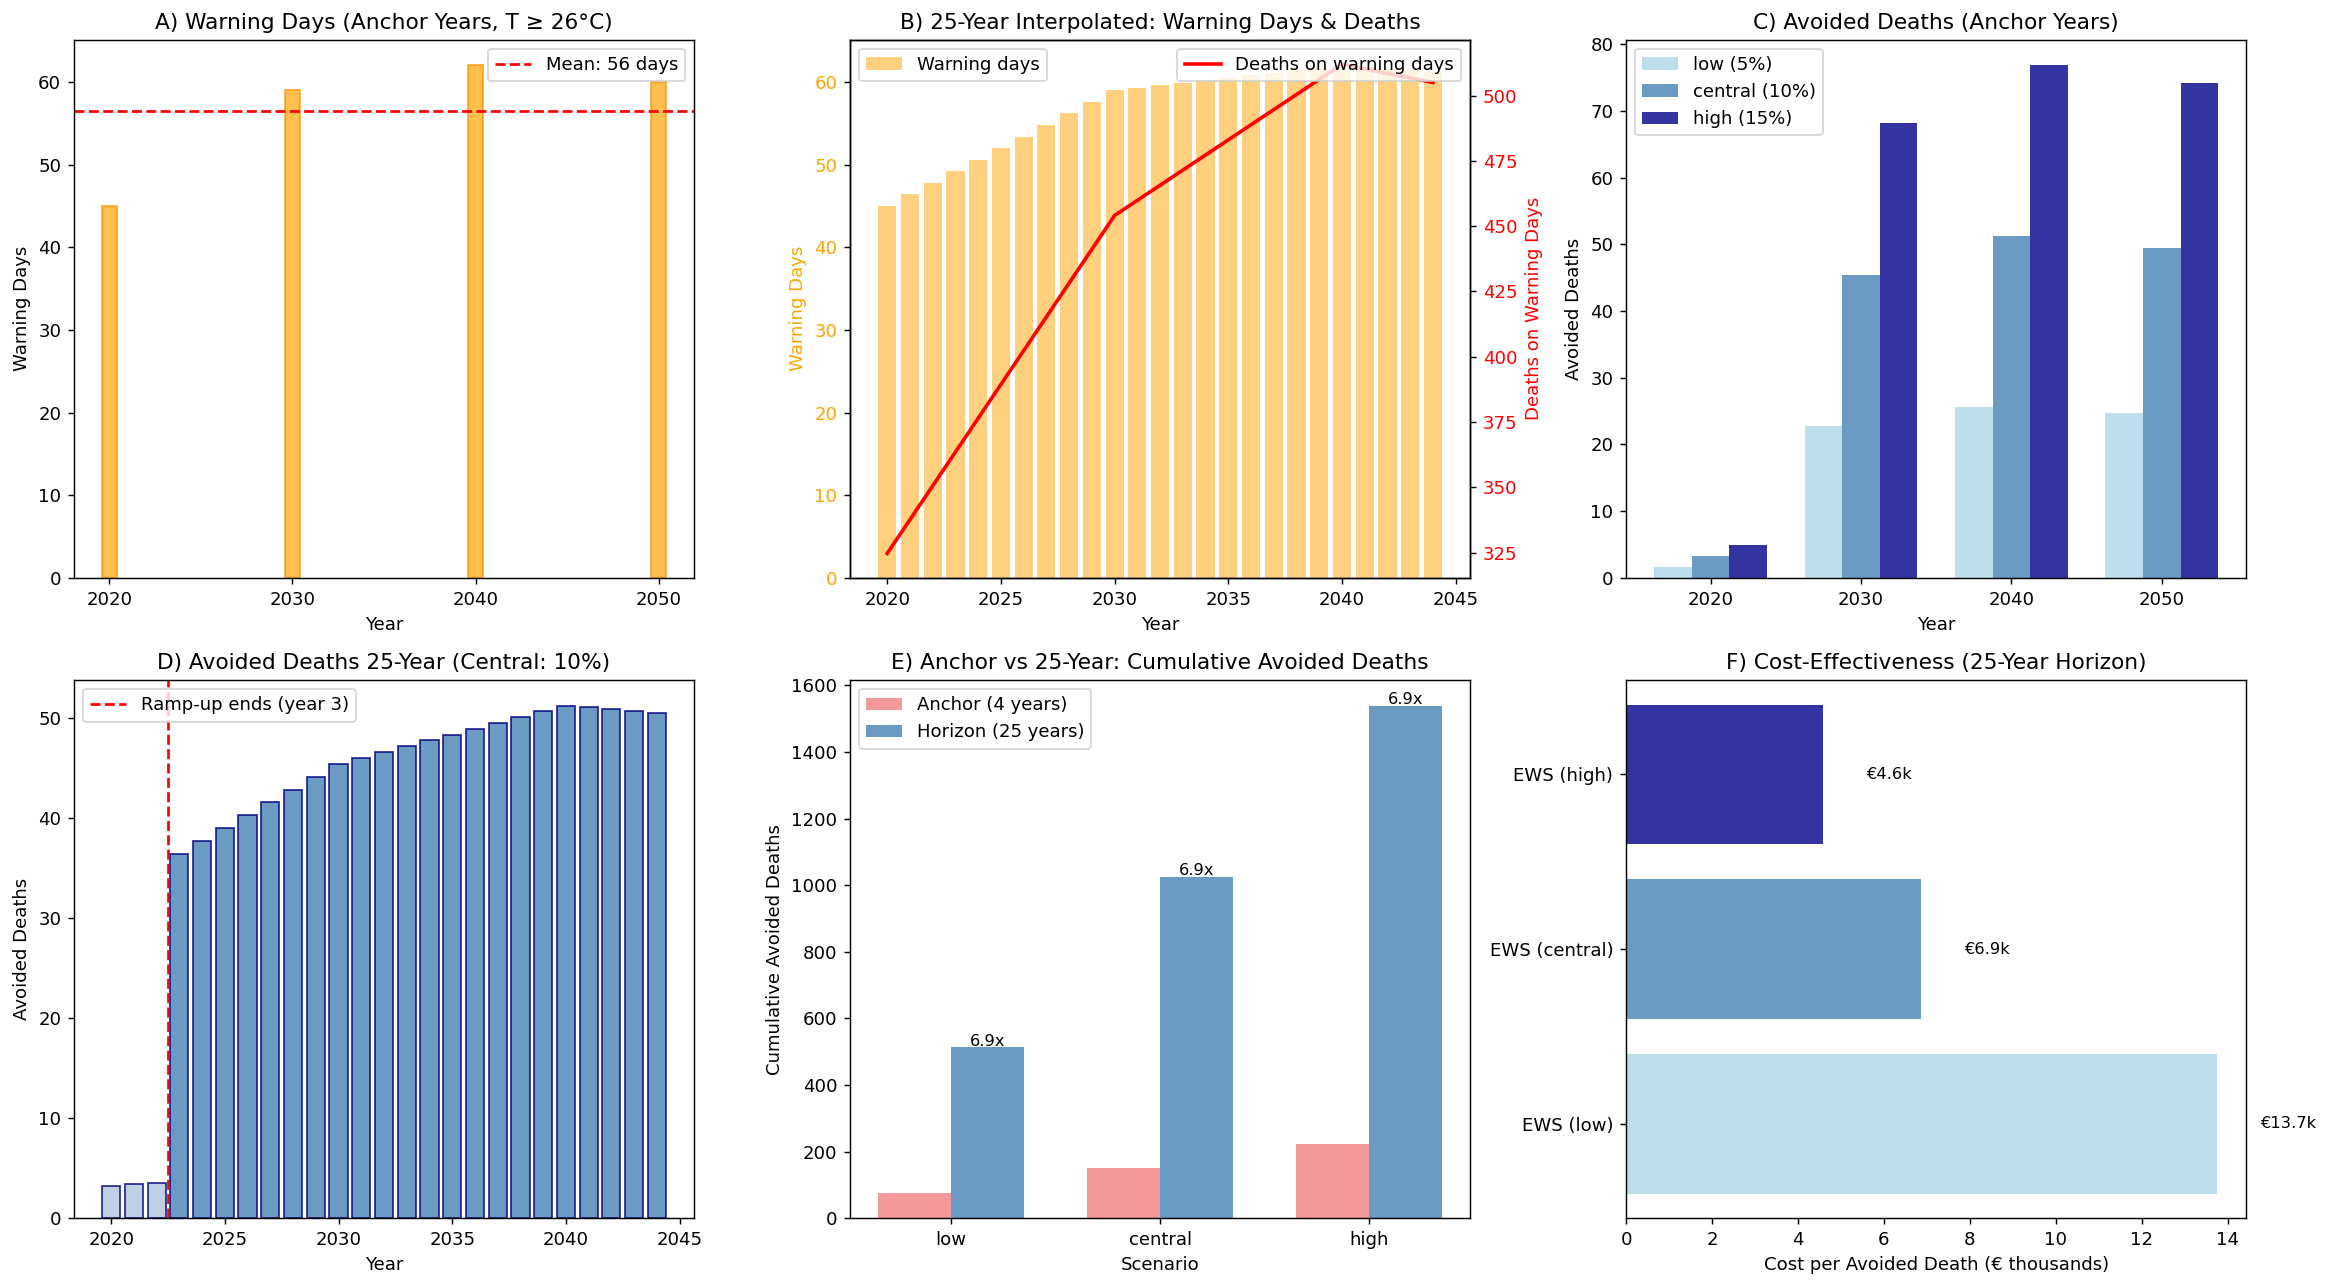

In [58]:
print("\n" + "=" * 70)
print("8. VISUALIZATION")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Panel A: Warning days by year (anchor)
ax = axes[0, 0]
years = warning_day_counts["year"]
days = warning_day_counts["n_warning_days"]
ax.bar(years, days, color="orange", alpha=0.7, edgecolor="darkorange")
ax.axhline(y=days.mean(), color="red", linestyle="--", label=f"Mean: {days.mean():.0f} days")
ax.set_xlabel("Year")
ax.set_ylabel("Warning Days")
ax.set_title(f"A) Warning Days (Anchor Years, T ≥ {thr:.0f}°C)")
ax.legend()
ax.set_xticks(years)

# Panel B: Warning days + deaths over 25 years (interpolated)
ax = axes[0, 1]
ax2 = ax.twinx()

# Warning days (bars)
ax.bar(YEARS_ALL, warning_days_25y, color="orange", alpha=0.5, label="Warning days")
ax.set_ylabel("Warning Days", color="orange")
ax.tick_params(axis='y', labelcolor="orange")

# Deaths on warning days (line)
ax2.plot(YEARS_ALL, deaths_warning_25y, 'r-', linewidth=2, label="Deaths on warning days")
ax2.set_ylabel("Deaths on Warning Days", color="red")
ax2.tick_params(axis='y', labelcolor="red")

ax.set_xlabel("Year")
ax.set_title("B) 25-Year Interpolated: Warning Days & Deaths")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")

# Panel C: Avoided deaths by scenario (anchor years)
ax = axes[0, 2]
width = 0.25
x = np.arange(len(YEARS_H))
scenarios = list(EFFICACY_SCENARIOS.keys())
colors = {"low": "lightblue", "central": "steelblue", "high": "darkblue"}
for i, scen in enumerate(scenarios):
    scen_data = ews_benefits_df[ews_benefits_df["scenario"] == scen]
    vals = scen_data["avoided_deaths"].values
    ax.bar(x + i*width, vals, width, label=f"{scen} ({EFFICACY_SCENARIOS[scen]*100:.0f}%)", 
           color=colors.get(scen, "gray"), alpha=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Avoided Deaths")
ax.set_title(f"C) Avoided Deaths (Anchor Years)")
ax.set_xticks(x + width)
ax.set_xticklabels(YEARS_H)
ax.legend()

# Panel D: Avoided deaths over 25 years (central scenario)
ax = axes[1, 0]
central_25y = EWS_25Y_DF[EWS_25Y_DF["scenario"] == "central"]

# Stacked: ramp period vs full efficacy
ramp_mask = central_25y["ramp_factor"] < 1.0
ax.bar(central_25y["year"], central_25y["avoided_deaths"], 
       color=np.where(ramp_mask, "lightsteelblue", "steelblue"), 
       alpha=0.8, edgecolor="navy")
ax.axvline(x=2020 + ramp_years - 0.5, color="red", linestyle="--", 
           label=f"Ramp-up ends (year {ramp_years})")
ax.set_xlabel("Year")
ax.set_ylabel("Avoided Deaths")
ax.set_title(f"D) Avoided Deaths 25-Year (Central: {EFFICACY_SCENARIOS['central']*100:.0f}%)")
ax.legend()

# Panel E: Cumulative avoided deaths comparison
ax = axes[1, 1]
scenarios = list(EFFICACY_SCENARIOS.keys())
anchor_vals = [cea_df[cea_df['scenario'] == s]['avoided_deaths_cum'].iloc[0] for s in scenarios]
horizon_vals = [EWS_25Y_SUMMARY[s]['avoided_deaths_cum'] for s in scenarios]

x = np.arange(len(scenarios))
width = 0.35
ax.bar(x - width/2, anchor_vals, width, label='Anchor (4 years)', color='lightcoral', alpha=0.8)
ax.bar(x + width/2, horizon_vals, width, label='Horizon (25 years)', color='steelblue', alpha=0.8)
ax.set_xlabel("Scenario")
ax.set_ylabel("Cumulative Avoided Deaths")
ax.set_title("E) Anchor vs 25-Year: Cumulative Avoided Deaths")
ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.legend()

# Add ratio labels
for i, (a, h) in enumerate(zip(anchor_vals, horizon_vals)):
    ax.text(i + width/2, h + 5, f"{h/a:.1f}x", ha='center', fontsize=9)

# Panel F: Cost-effectiveness (25-year, for NB8 comparison)
ax = axes[1, 2]

# Build comparison with other policies 
comparison_25y = pd.DataFrame([
    {"policy": f"EWS ({s})", "cost_per_avoided_death_eur": EWS_25Y_SUMMARY[s]["cost_per_death_cum"]}
    for s in scenarios
])

policies = comparison_25y["policy"]
costs = comparison_25y["cost_per_avoided_death_eur"] / 1e3  # In thousands

bars = ax.barh(policies, costs, color=["lightblue", "steelblue", "darkblue"], alpha=0.8)
ax.set_xlabel("Cost per Avoided Death (€ thousands)")
ax.set_title("F) Cost-Effectiveness (25-Year Horizon)")

for i, bar in enumerate(bars):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f"€{costs.iloc[i]:.1f}k", va='center', fontsize=9)

plt.tight_layout()
fig_path = OUT / "figures" / f"{SLUG}_ews_summary_25y.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"  Saved: {fig_path}")
plt.show()

# 8. SAVE OUTPUTS

In [59]:
print("\n" + "=" * 70)
print("8. SAVING OUTPUTS")
print("=" * 70)

tables_dir = OUT / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

# 8.1 Warning days (anchor years)
warning_output = warning_day_counts.copy()
warning_output["threshold_c"] = thr
warning_output["threshold_method"] = thr_meta["method"]
warning_output.to_csv(tables_dir / f"{SLUG}_ews_warning_days.csv", index=False)
print(f"  Saved: {SLUG}_ews_warning_days.csv")

# 8.2 Annual baseline deaths under current AC (anchor years, for NB8)
baseline_output = annual_base[["year", "deaths_overall", "deaths_on_warning_days", 
                               "frac_deaths_on_warning_days", "n_warning_days"]].copy()
baseline_output.to_csv(tables_dir / f"annual_heat_deaths_baseline_current_ac_{SLUG}.csv", index=False)
print(f"  Saved: annual_heat_deaths_baseline_current_ac_{SLUG}.csv")

# 8.3 EWS avoided deaths - anchor years (long format)
ews_benefits_df.to_csv(tables_dir / f"annual_heat_deaths_avoided_EWS_{SLUG}.csv", index=False)
print(f"  Saved: annual_heat_deaths_avoided_EWS_{SLUG}.csv")

# 8.4 EWS avoided deaths - 25-year horizon (long format, for NB8)
EWS_25Y_DF.to_csv(tables_dir / f"ews_benefits_25y_{SLUG}.csv", index=False)
print(f"  Saved: ews_benefits_25y_{SLUG}.csv")

# 8.5 EWS time series - 25-year horizon (for NB8)
ews_timeseries_25y = pd.DataFrame({
    "year": YEARS_ALL,
    "warning_days": warning_days_25y,
    "deaths_on_warning_days": deaths_warning_25y,
    "ramp_factor": ramp_factor_25y,
    "cost_capex": cost_capex_25y,
    "cost_opex": cost_opex_25y,
    "cost_total": cost_total_25y,
    "cost_pv": cost_pv_25y,
    "discount_factor": discount_factors_25y,
})
ews_timeseries_25y.to_csv(tables_dir / f"ews_timeseries_25y_{SLUG}.csv", index=False)
print(f"  Saved: ews_timeseries_25y_{SLUG}.csv")

# 8.6 Costs - anchor years
costs_df.to_csv(tables_dir / f"{SLUG}_ews_costs_annual.csv", index=False)
print(f"  Saved: {SLUG}_ews_costs_annual.csv")

# 8.7 Cost-effectiveness - anchor years
cea_df.to_csv(tables_dir / f"{SLUG}_ews_cea.csv", index=False)
print(f"  Saved: {SLUG}_ews_cea.csv")

# 8.8 Cost-effectiveness - 25-year horizon
cea_25y_df.to_csv(tables_dir / f"{SLUG}_ews_cea_25y.csv", index=False)
print(f"  Saved: {SLUG}_ews_cea_25y.csv")

# 8.9 Parameters JSON (for reproducibility)
params = {
    "city": CITY,
    "slug": SLUG,
    "interpretation": EWS_CONFIG["interpretation"],
    "threshold": {
        "value_c": thr,
        **thr_meta
    },
    "warning_months": EWS_CONFIG["warning_months"],
    "efficacy_scenarios": EFFICACY_SCENARIOS,
    "ramp": {
        "years": EWS_CONFIG["ramp_years"],
        "initial_efficacy": EWS_CONFIG["ramp_initial_efficacy"]
    },
    "costs": {
        "capex_setup": EWS_CONFIG["capex_setup"],
        "opex_per_warning_day": EWS_CONFIG["opex_per_warning_day"],
        "opex_annual_fixed": EWS_CONFIG["opex_annual_fixed"],
        "pv_total_anchor": float(pv_total_cost),
        "pv_total_25y": float(PV_EWS_COST_25Y),
    },
    "discount_rate": DISCOUNT_RATE,
    "horizon_years": HORIZON_YEARS,
    "study_years": YEARS_H,
    "baseline_definition": "deaths under current AC coverage (from NB5)",
    # 25-year summary for NB8
    "horizon_25y": {
        "years": YEARS_ALL.tolist(),
        "pv_cost_total": float(PV_EWS_COST_25Y),
        "summary_by_scenario": {
            scen: {k: float(v) for k, v in vals.items()} 
            for scen, vals in EWS_25Y_SUMMARY.items()
        }
    }
}
with open(tables_dir / f"{SLUG}_ews_parameters.json", "w") as f:
    json.dump(params, f, indent=2)
print(f"  Saved: {SLUG}_ews_parameters.json")

print(f"\n  Total files saved: 9")


8. SAVING OUTPUTS
  Saved: rome_ews_warning_days.csv
  Saved: annual_heat_deaths_baseline_current_ac_rome.csv
  Saved: annual_heat_deaths_avoided_EWS_rome.csv
  Saved: ews_benefits_25y_rome.csv
  Saved: ews_timeseries_25y_rome.csv
  Saved: rome_ews_costs_annual.csv
  Saved: rome_ews_cea.csv
  Saved: rome_ews_cea_25y.csv
  Saved: rome_ews_parameters.json

  Total files saved: 9


# 9. SUMMARY

In [60]:
print("\n" + "=" * 70)
print("SUMMARY: Early Warning System Policy Analysis")
print("=" * 70)

# Central scenario values for summary
central_anchor = cea_df[cea_df['scenario'] == 'central'].iloc[0]
central_25y = EWS_25Y_SUMMARY['central']

print(f"""
City: {CITY}
Interpretation: {EWS_CONFIG['interpretation'].upper()}
  {'Counterfactual: Shows benefit of existing HHWWS' if EWS_CONFIG['interpretation'] == 'counterfactual' 
   else '✓ Marginal: Benefit of enhancement (baseline embeds existing HHWWS)'}

Warning System:
  Threshold: {thr:.1f}°C (warm season months {EWS_CONFIG['warning_months']})
  Warning days: {warning_day_counts['n_warning_days'].mean():.0f}/year average (anchor)
  Warning days: {warning_days_25y.mean():.0f}/year average (25-year interpolated)
  Deaths on warning days: {annual_base['frac_deaths_on_warning_days'].mean()*100:.1f}% of annual heat deaths

Benefits (central scenario, {EFFICACY_SCENARIOS['central']*100:.0f}% efficacy):
  ┌─────────────────────────────────────────────────────────────────┐
  │                    Anchor (4 years)    25-Year Horizon          │
  ├─────────────────────────────────────────────────────────────────┤
  │ Avoided deaths:     {central_anchor['avoided_deaths_cum']:>10.1f}         {central_25y['avoided_deaths_cum']:>10.1f}           │
  │ Cost per death:     €{central_anchor['cost_per_avoided_death_cum_eur']:>9,.0f}         €{central_25y['cost_per_death_cum']:>9,.0f}           │
  └─────────────────────────────────────────────────────────────────┘

Costs:
  CAPEX: €{EWS_CONFIG['capex_setup']:,} (one-time)
  OPEX:  €{EWS_CONFIG['opex_annual_fixed']:,}/year fixed + €{EWS_CONFIG['opex_per_warning_day']:,}/warning day
  
  PV total (anchor 4 years): €{pv_total_cost:,.0f}
  PV total (25-year horizon): €{PV_EWS_COST_25Y:,.0f}

Cost-Effectiveness by Scenario (25-year horizon):
""")

for scen, vals in EWS_25Y_SUMMARY.items():
    eff_pct = EFFICACY_SCENARIOS[scen] * 100
    print(f"  {scen} ({eff_pct:.0f}%): {vals['avoided_deaths_cum']:.0f} deaths avoided, "
          f"€{vals['cost_per_death_cum']:,.0f}/death")

print(f"""
Ratio (25y / 4y):
  Avoided deaths: {central_25y['avoided_deaths_cum'] / central_anchor['avoided_deaths_cum']:.2f}x
  Costs:          {PV_EWS_COST_25Y / pv_total_cost:.2f}x

Key Methodological Notes:
1. Baseline = deaths under current AC (consistent with NB7 vegetation and NB5 AC)
2. Deaths on warning days computed endogenously (not assumed fraction)
3. EWS efficacy applies ONLY to warning-day deaths
4. Ramp-up: {EWS_CONFIG['ramp_years']} years at {EWS_CONFIG['ramp_initial_efficacy']*100:.0f}% efficacy, then full
5. Double-counting caveat addressed via {EWS_CONFIG['interpretation']} interpretation

Files for NB8 CBA:
  - ews_benefits_25y_{SLUG}.csv (avoided deaths by year and scenario)
  - ews_timeseries_25y_{SLUG}.csv (costs and warning days by year)
  - {SLUG}_ews_parameters.json (all parameters including 25y summary)
""")

print("=" * 70)
print(f"Notebook 6 complete. Outputs saved to: {tables_dir}")
print("=" * 70)


SUMMARY: Early Warning System Policy Analysis

City: Rome
Interpretation: MARGINAL
  ✓ Marginal: Benefit of enhancement (baseline embeds existing HHWWS)

Warning System:
  Threshold: 26.0°C (warm season months [5, 6, 7, 8, 9])
  Warning days: 56/year average (anchor)
  Warning days: 57/year average (25-year interpolated)
  Deaths on warning days: 79.9% of annual heat deaths

Benefits (central scenario, 10% efficacy):
  ┌─────────────────────────────────────────────────────────────────┐
  │                    Anchor (4 years)    25-Year Horizon          │
  ├─────────────────────────────────────────────────────────────────┤
  │ Avoided deaths:          149.3             1026.1           │
  │ Cost per death:     €    7,791         €    6,874           │
  └─────────────────────────────────────────────────────────────────┘

Costs:
  CAPEX: €140,000 (one-time)
  OPEX:  €50,000/year fixed + €6,000/warning day
  
  PV total (anchor 4 years): €1,163,180
  PV total (25-year horizon): €7,053,